In [13]:
#%% Ячейка 1: Установка и импорт библиотек
import sys, subprocess, os
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])
try:
    import pmdarima, tensorflow
except ImportError:
    install("pmdarima")
    install("tensorflow")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
print("Библиотеки загружены.")

Библиотеки загружены.


In [ ]:
#%% Ячейка 2: Загрузка данных и настройка путей
base_dir = r'C:\Poly\Диплом'
preproc_dir = os.path.join(base_dir, 'Предобработанные данные')
vis_dir = os.path.join(base_dir, 'Визуализация/Глава 7')
os.makedirs(vis_dir, exist_ok=True)

valuations = pd.read_csv(os.path.join(preproc_dir, 'player_valuations_preprocessed.csv'))
attrs = pd.read_csv(os.path.join(preproc_dir, 'player_attributes_preprocessed.csv'))

valuations['date'] = pd.to_datetime(valuations['date'])
attrs['update_as_of'] = pd.to_datetime(attrs['update_as_of'], errors='coerce')
print(f"Valuations: {valuations.shape}, Attributes: {attrs.shape}")

In [ ]:
#%% Ячейка 3: Выбор топ-игроков для анализа

N_PLAYERS = 20

player_counts = valuations['player_id'].value_counts()
top_player_ids = player_counts.index[:N_PLAYERS].tolist()

print(f"Будут проанализированы {N_PLAYERS} игроков с наибольшим количеством записей:")
print(top_player_ids)

def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

def metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true[y_true != 0] - y_pred[y_true != 0]) / y_true[y_true != 0])) * 100
    print(f"{name:25} RMSE: {rmse:10.2f} | MAE: {mae:10.2f} | R2: {r2:7.3f} | MAPE: {mape:5.1f}%")

Будут проанализированы 20 игроков с наибольшим количеством записей:
[179184, 238809, 152733, 68863, 114422, 111275, 51894, 216662, 238266, 162038, 168157, 294767, 39333, 206050, 278654, 205562, 105521, 182877, 186590, 183288]


In [ ]:
#%% Ячейка 4: Функция обработки одного игрока (БЕЗ аугментации)

def process_player(player_id):
    print(f"\n{'='*70}")
    print(f"ОБРАБОТКА ИГРОКА ID = {player_id}")
    print(f"{'='*70}")
    
    # 1. Загрузка данных игрока
    player_raw = valuations[valuations['player_id'] == player_id].copy()
    if len(player_raw) < 20:
        print(f"Слишком мало данных ({len(player_raw)} записей). Пропускаем.")
        return None
    
    player_raw = player_raw.sort_values('date')
    
    # 2. Агрегация по месяцам (БЕЗ заполнения пропусков)
    player_raw['month'] = player_raw['date'].dt.to_period('M').dt.to_timestamp()
    df = player_raw.groupby('month')['market_value_in_eur'].mean().to_frame()
    df.index = pd.to_datetime(df.index)   # приводим к datetime
    df = df.sort_index()
    
    print(f"Исходных записей: {len(player_raw)} → после агрегации: {len(df)} месяцев")
    
    # 3. Train / Test split
    cutoff = int(len(df) * 0.75)
    train = df.iloc[:cutoff]
    test = df.iloc[cutoff:]
    
    # 4. ARIMA
    try:
        arima = ARIMA(train['market_value_in_eur'], order=(2,1,2)).fit()
        arima_pred = arima.forecast(len(test))
    except:
        arima_pred = pd.Series([np.nan] * len(test), index=test.index)
    
    # 5. Exponential Smoothing
    try:
        exp = ExponentialSmoothing(train['market_value_in_eur'], 
                                   seasonal='add', seasonal_periods=12).fit()
        exp_pred = exp.forecast(len(test))
    except:
        exp_pred = pd.Series([np.nan] * len(test), index=test.index)
    
    # 6. LSTM
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[['market_value_in_eur']])
    
    X, y = create_sequences(scaled, seq_length=12)
    
    lstm_pred = None
    history = None
    if len(X) >= 15:
        train_size = int(len(X) * 0.8)
        X_train, X_test = X[:train_size], X[train_size:]
        y_train, y_test = y[:train_size], y[train_size:]
        
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=(12, 1)),
            Dropout(0.2),
            LSTM(32),
            Dropout(0.2),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
        
        history = model.fit(X_train, y_train, epochs=80, batch_size=16,
                            validation_split=0.2, callbacks=[early_stop], verbose=0)
        
        # Итеративный прогноз
        last_window = train['market_value_in_eur'].values[-12:]
        last_scaled = scaler.transform(last_window.reshape(-1, 1))
        current = last_scaled.copy()
        lstm_forecast = []
        
        for _ in range(len(test)):
            pred_scaled = model.predict(current.reshape(1, 12, 1), verbose=0)
            pred = scaler.inverse_transform(pred_scaled)[0, 0]
            lstm_forecast.append(pred)
            current = np.vstack((current[1:], pred_scaled))
        
        lstm_pred = np.array(lstm_forecast)
    else:
        lstm_pred = np.full(len(test), np.nan)
    
    # Сохранение результатов
    results[player_id] = {
        'train': train,
        'test': test,
        'arima_pred': arima_pred,
        'exp_pred': exp_pred,
        'lstm_pred': lstm_pred,
        'history': history,
        'player_monthly': df
    }
    
    # Метрики
    print(f"Результаты для ID {player_id}:")
    metrics(test['market_value_in_eur'].values, arima_pred.values, "ARIMA")
    metrics(test['market_value_in_eur'].values, exp_pred.values, "Exp Smoothing")
    if lstm_pred is not None and not np.isnan(lstm_pred).all():
        metrics(test['market_value_in_eur'].values, lstm_pred, "LSTM")
    
    return results[player_id]

In [ ]:
#%% Ячейка 5: Запуск обработки нескольких игроков

results = {}   # главный словарь

for pid in top_player_ids:
    process_player(pid)


ОБРАБОТКА ИГРОКА ID = 179184
Исходных записей: 40 → после агрегации: 40 месяцев
Результаты для ID 179184:
ARIMA                     RMSE: 6072705.26 | MAE: 5284403.76 | R2:  -6.931 | MAPE: 106.3%
Exp Smoothing             RMSE: 9158839.05 | MAE: 7578015.29 | R2: -17.040 | MAPE: 149.1%
LSTM                      RMSE: 2123186.76 | MAE: 1546228.25 | R2:   0.031 | MAPE:  34.8%

ОБРАБОТКА ИГРОКА ID = 238809
Исходных записей: 40 → после агрегации: 40 месяцев
Результаты для ID 238809:
ARIMA                     RMSE: 1420563.27 | MAE: 1320000.00 | R2:  -6.322 | MAPE:  76.6%
Exp Smoothing             RMSE: 1060377.15 | MAE:  956510.77 | R2:  -3.080 | MAPE:  50.7%
LSTM                      RMSE:  783868.83 | MAE:  717771.97 | R2:  -1.230 | MAPE:  41.8%

ОБРАБОТКА ИГРОКА ID = 152733
Исходных записей: 39 → после агрегации: 39 месяцев
Результаты для ID 152733:
ARIMA                     RMSE: 2630607.96 | MAE: 2247500.00 | R2:  -4.274 | MAPE: 219.3%
Exp Smoothing             RMSE: 1870712.69 | MAE:

ValueError: Input contains NaN.

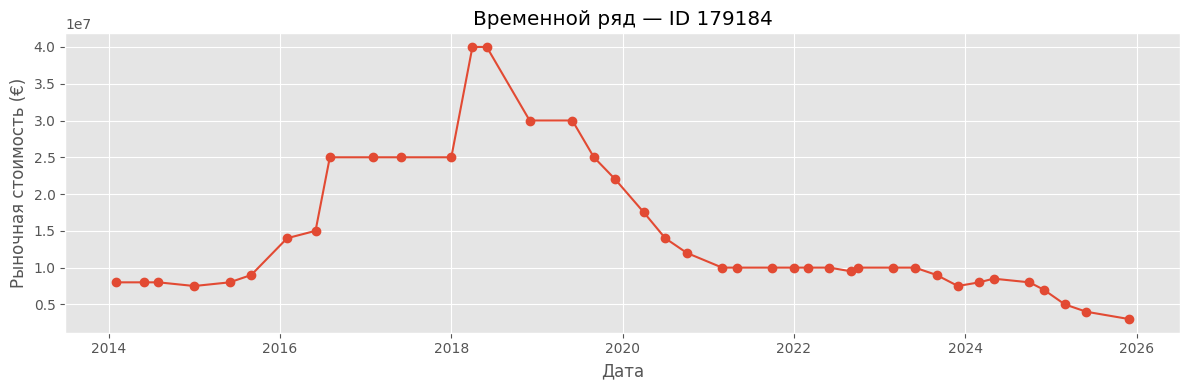

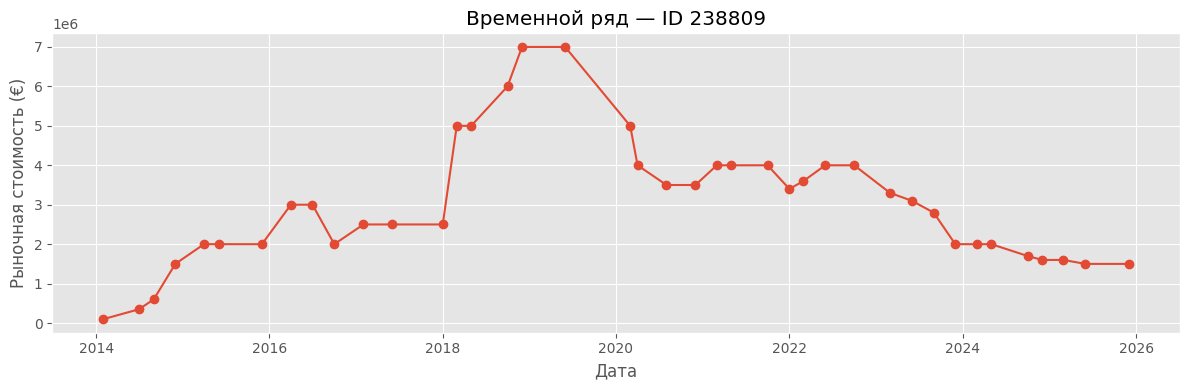

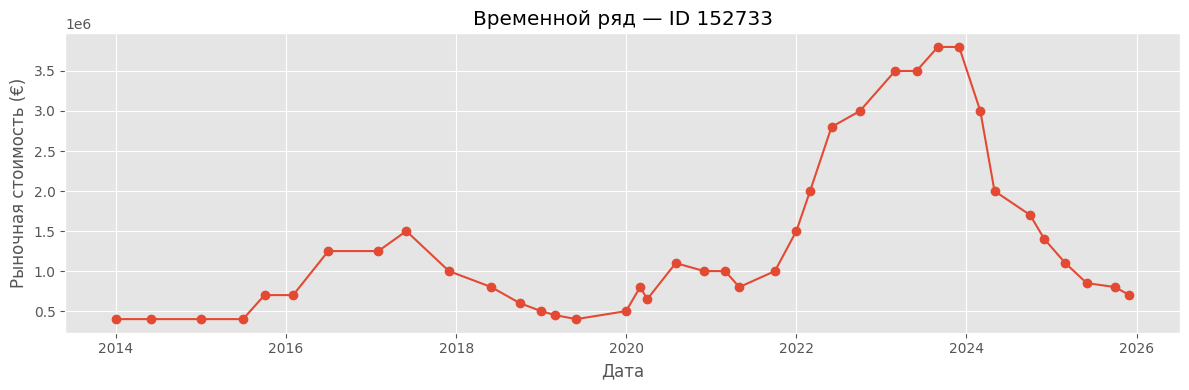

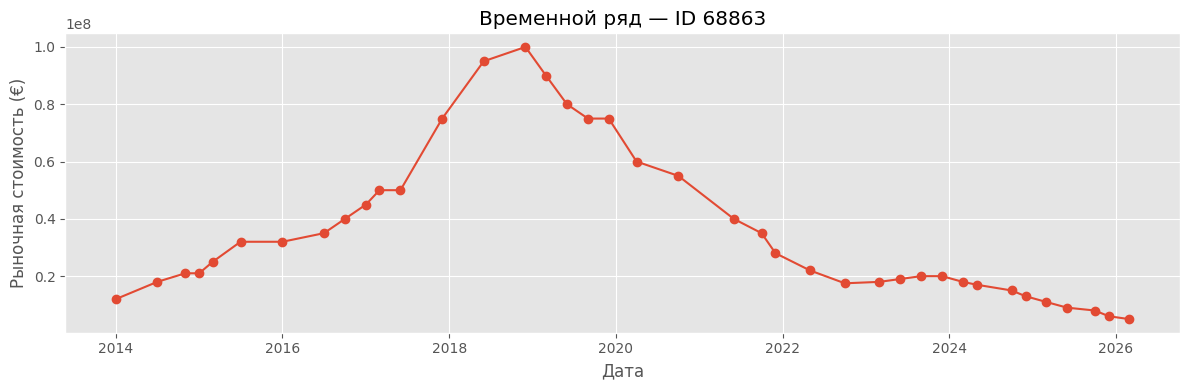

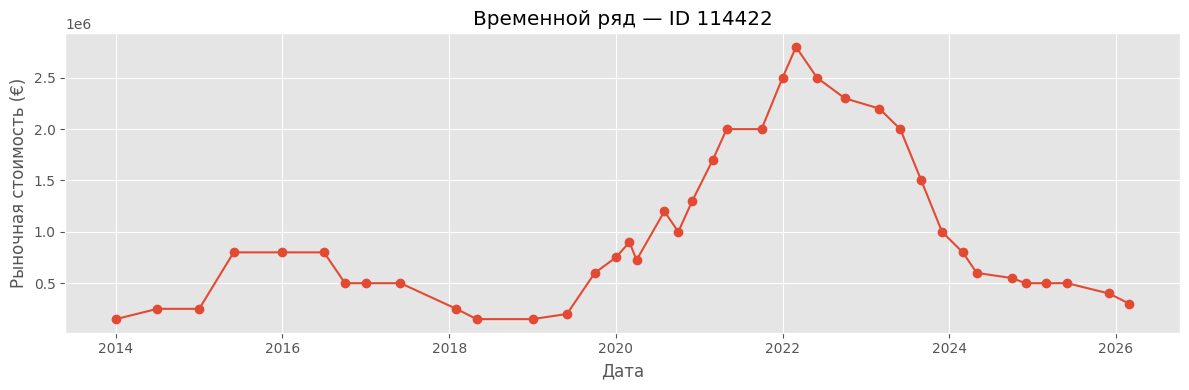

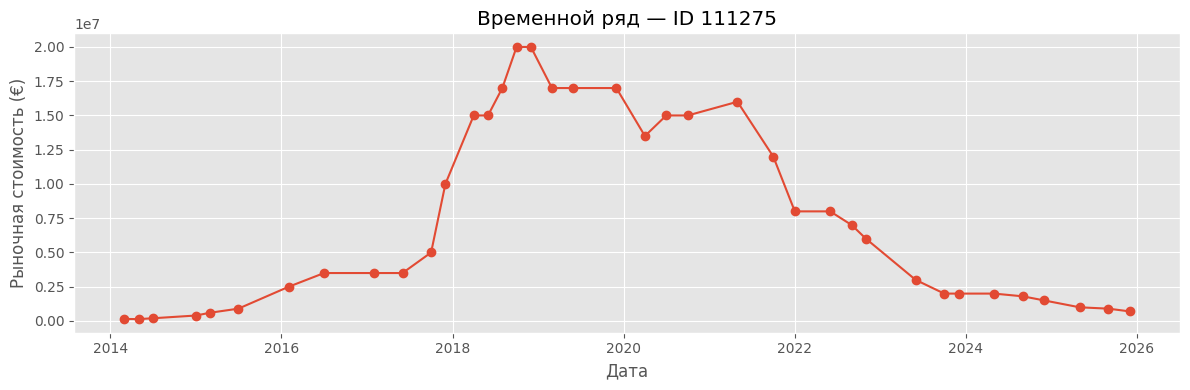

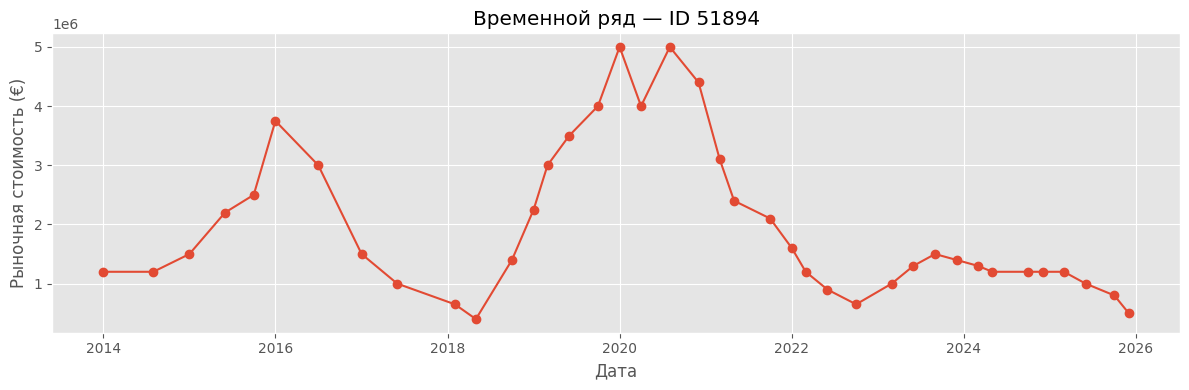

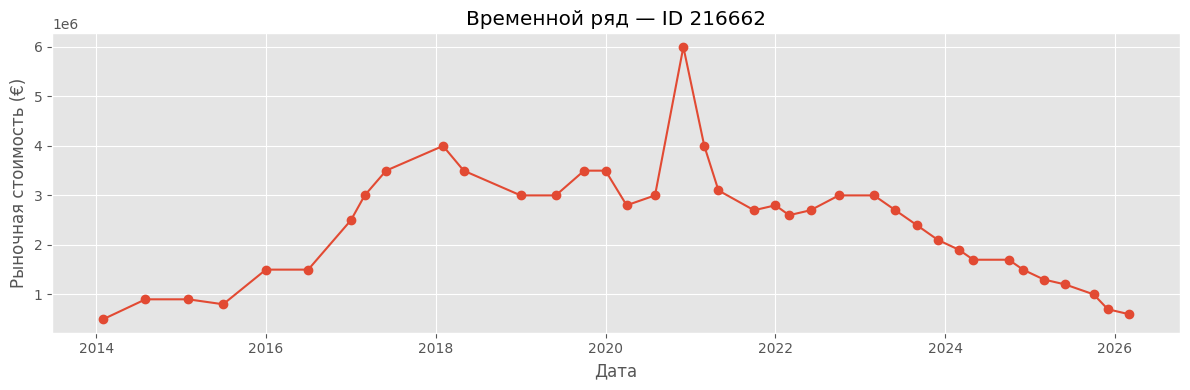

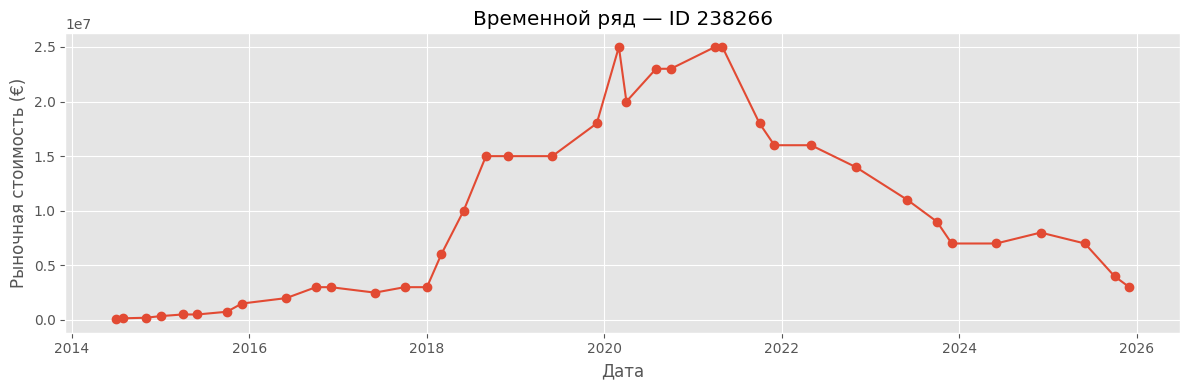

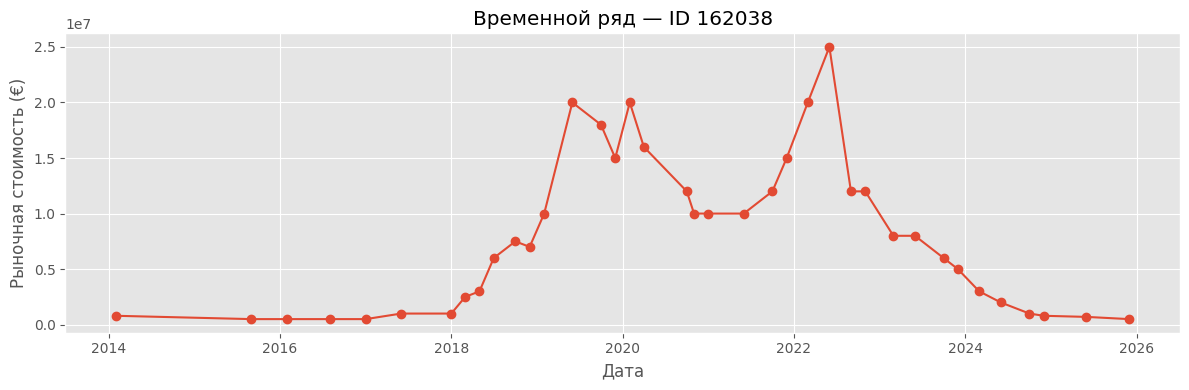

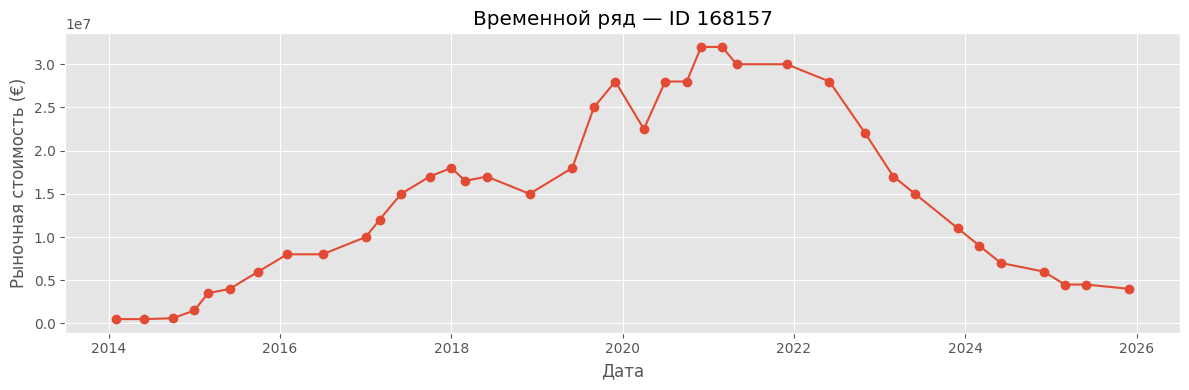

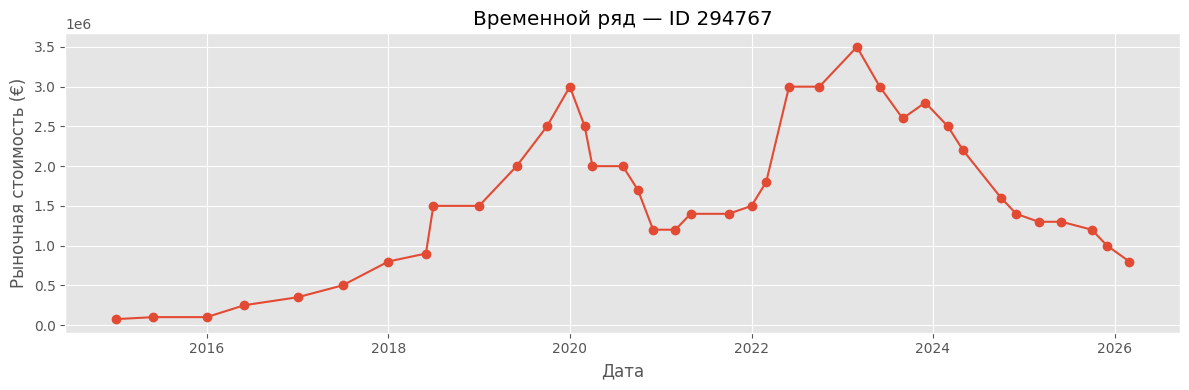

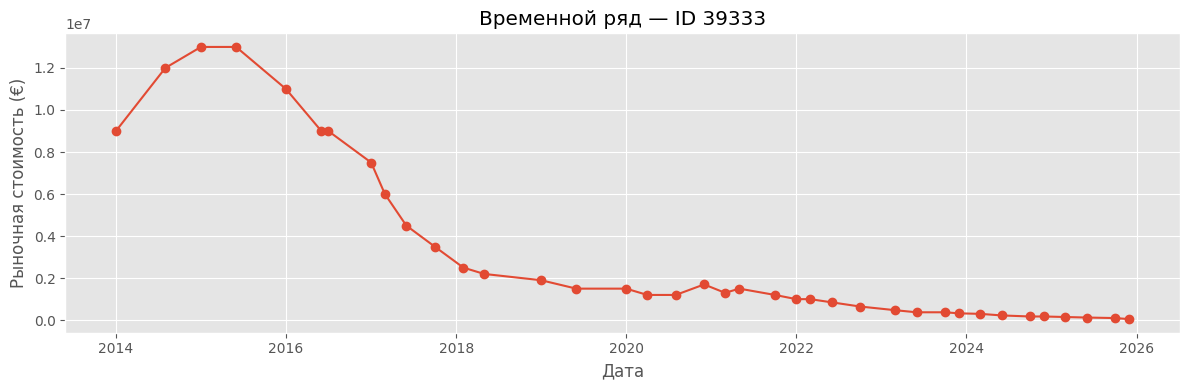

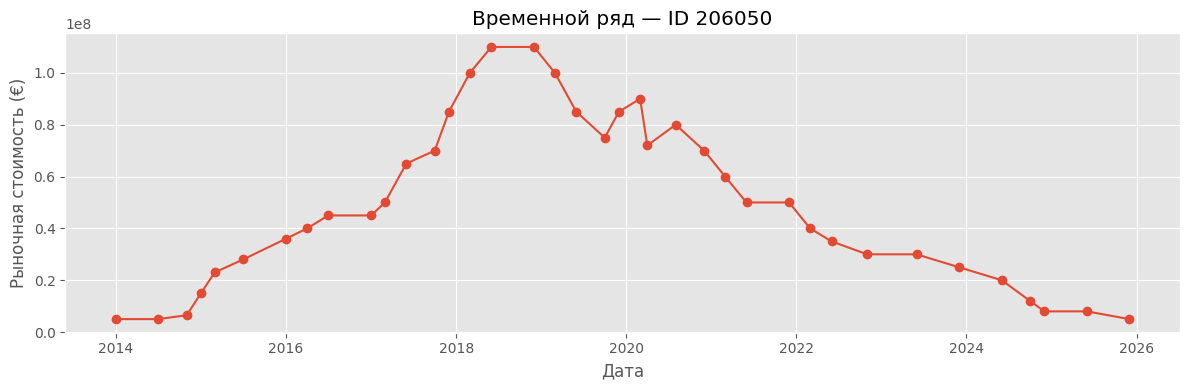

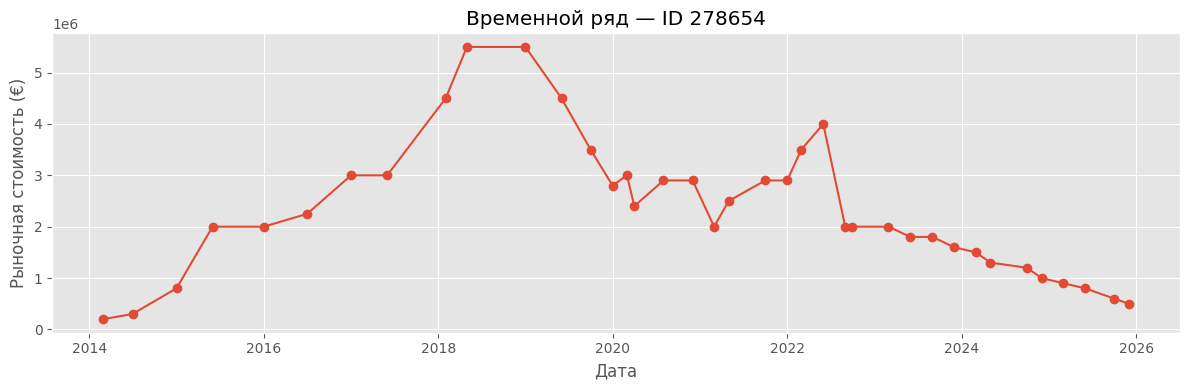

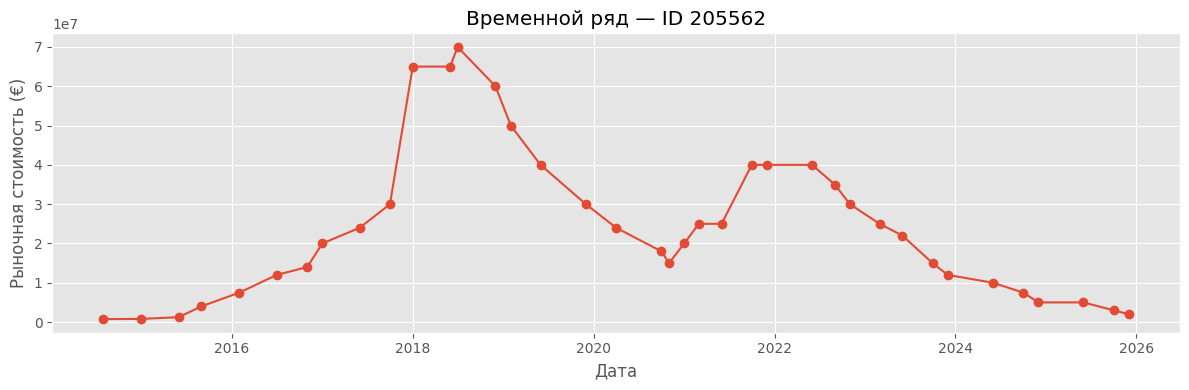

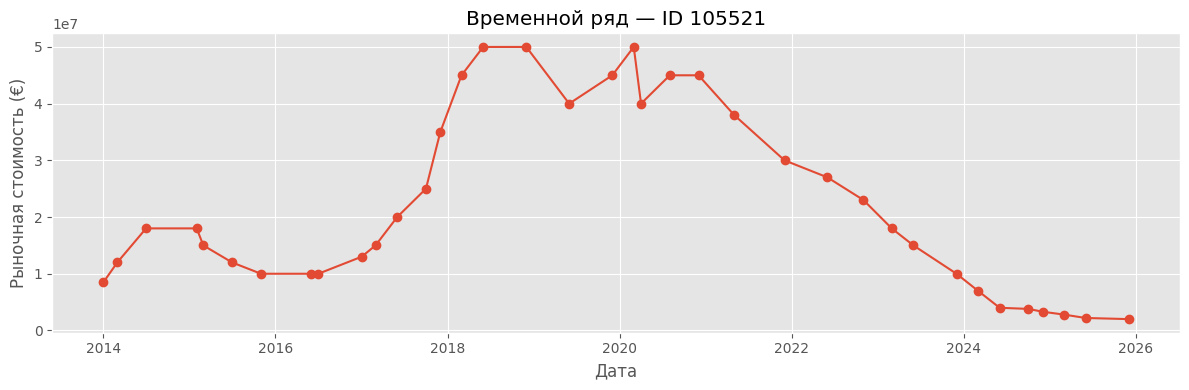

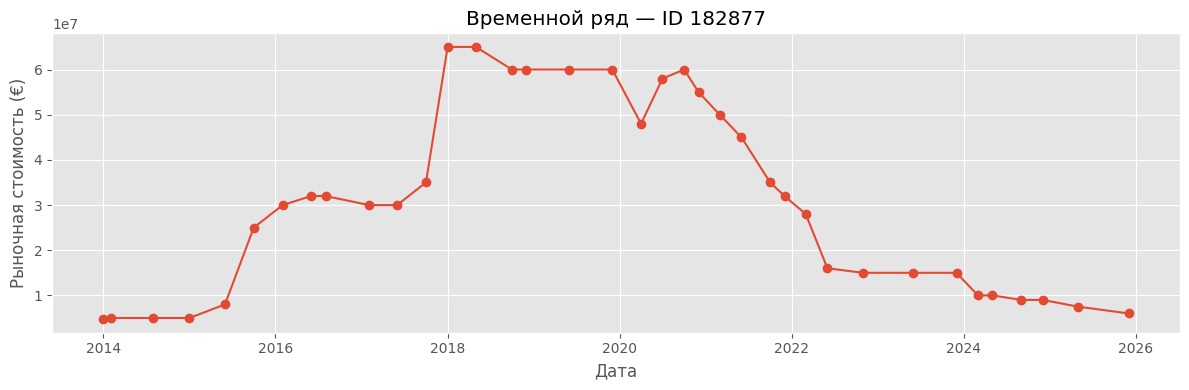

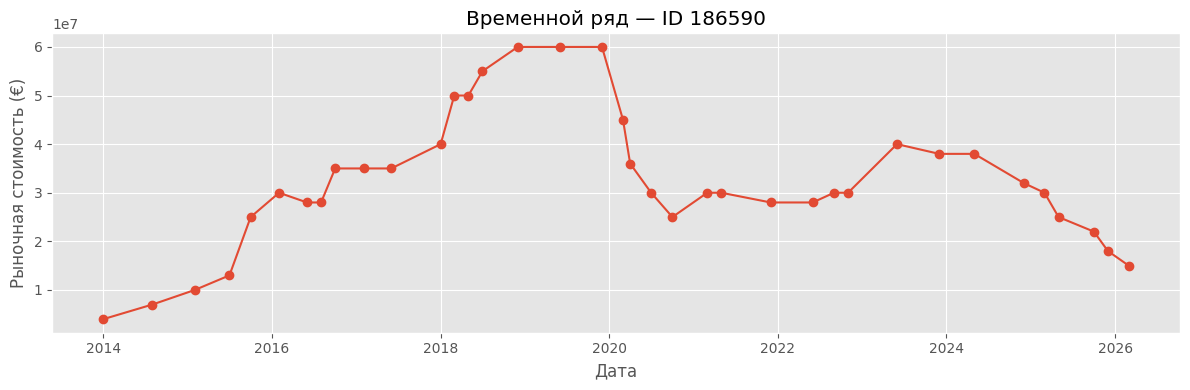

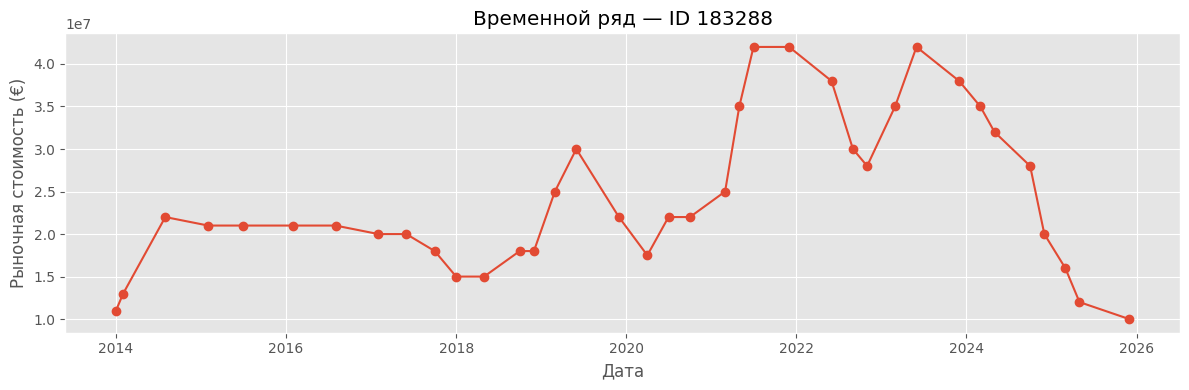

In [ ]:
#%% Ячейка 6: Графики аугментированных рядов

for pid in top_player_ids:
    if pid in results:
        df = results[pid]['player_monthly']
        plt.figure(figsize=(12, 4))
        plt.plot(df.index, df['market_value_in_eur'], marker='o', linewidth=1.5)
        plt.title(f'Временной ряд — ID {pid}')
        plt.xlabel('Дата')
        plt.ylabel('Рыночная стоимость (€)')
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(vis_dir, f'{pid}.png'), dpi=200)
        plt.show()

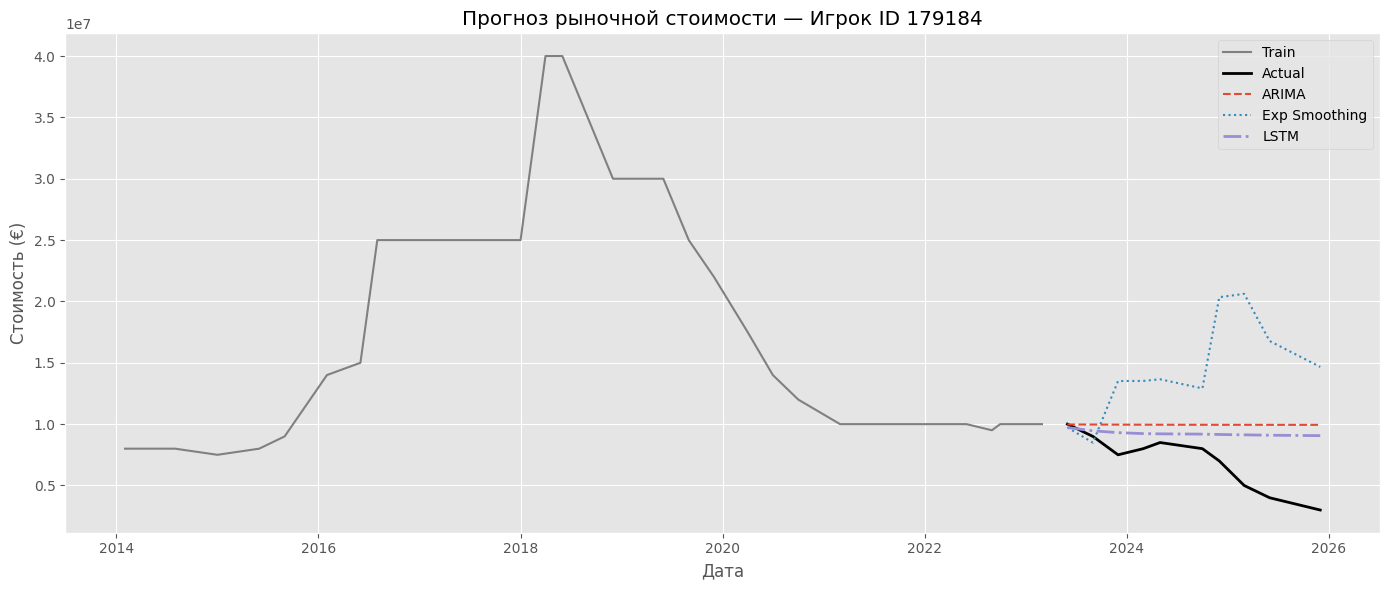

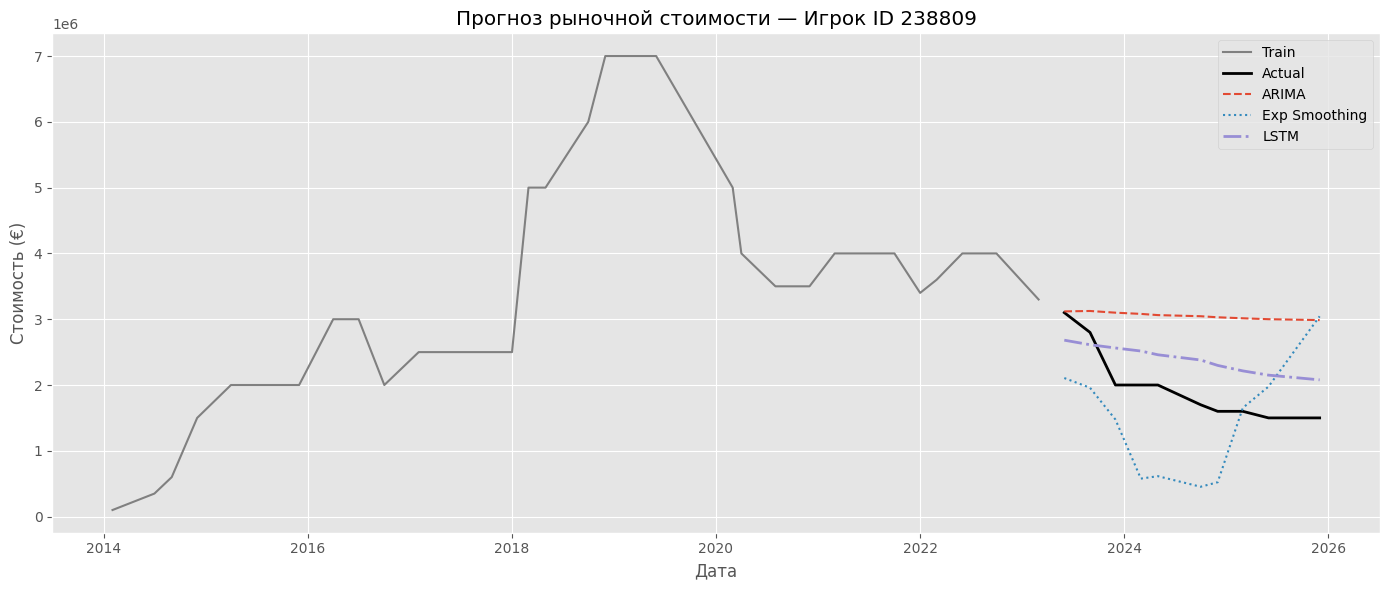

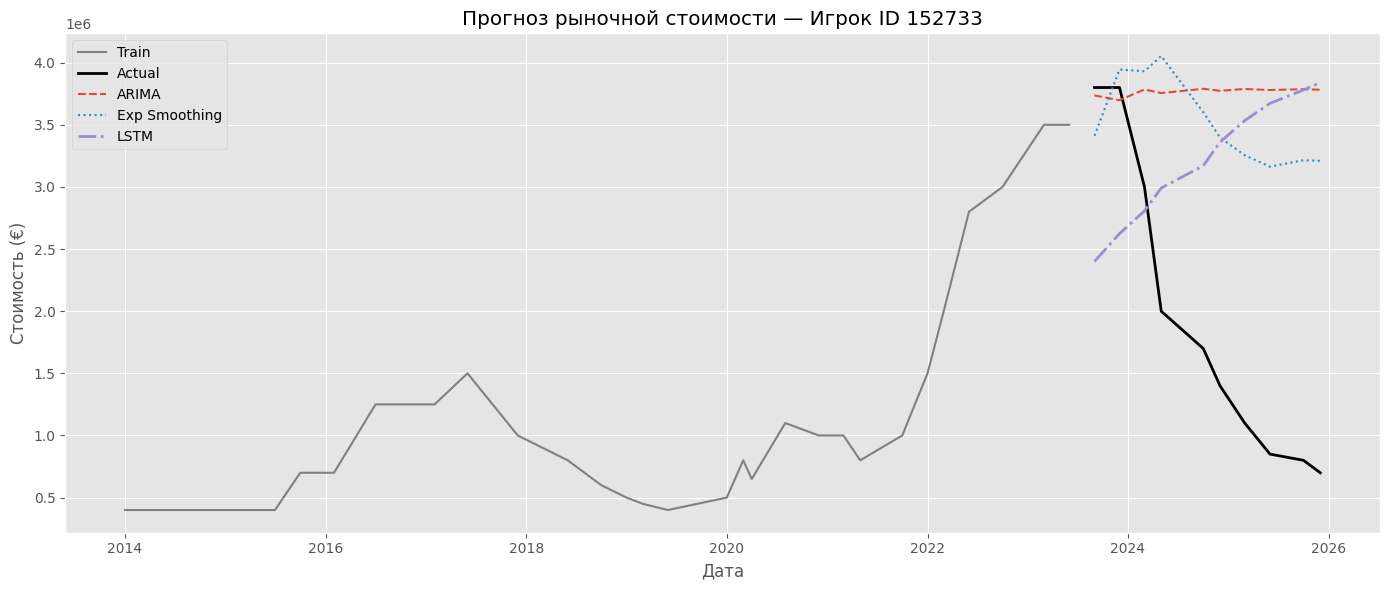

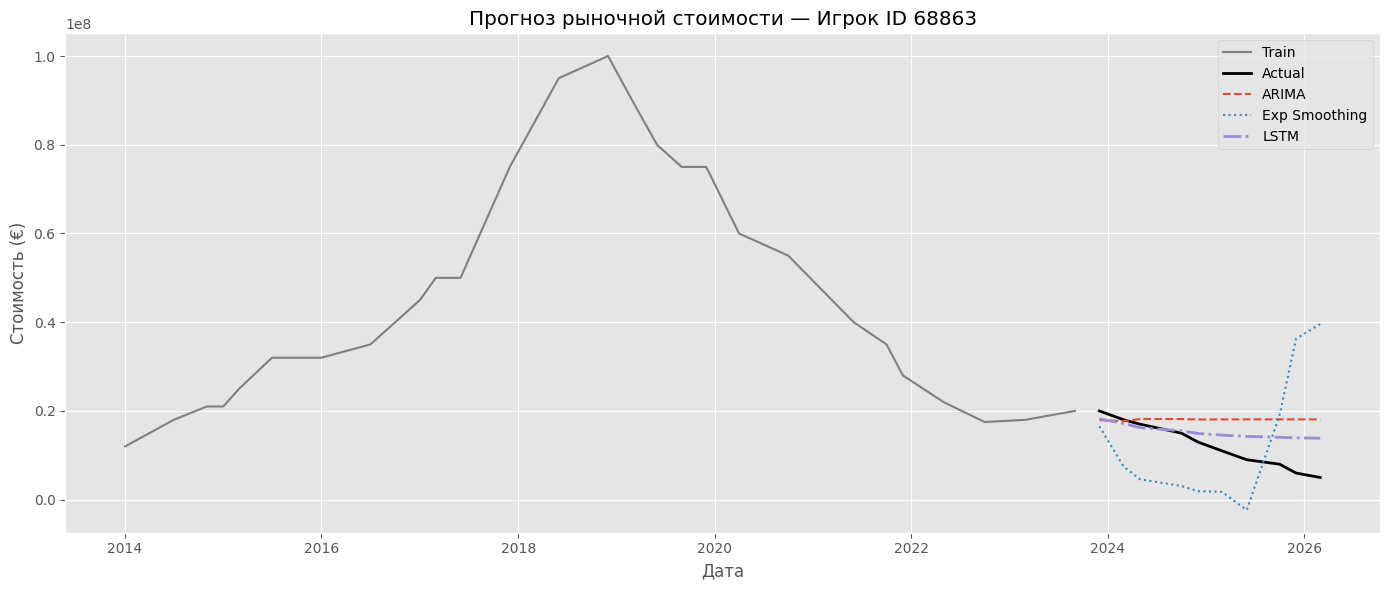

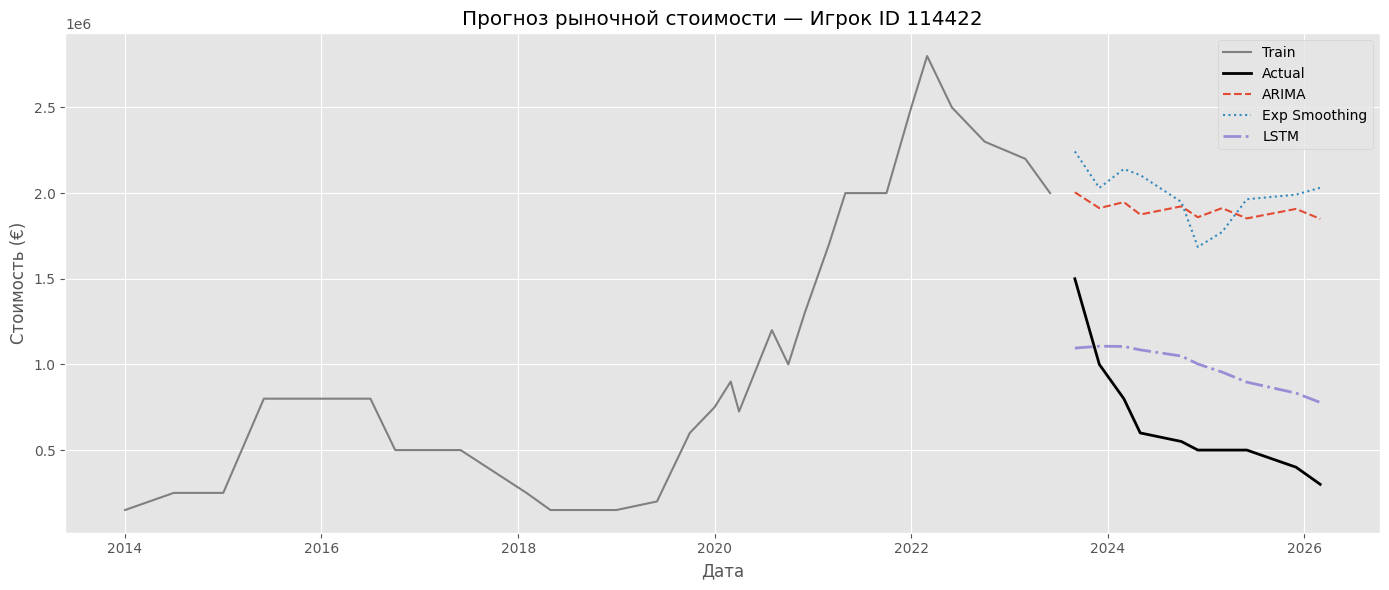

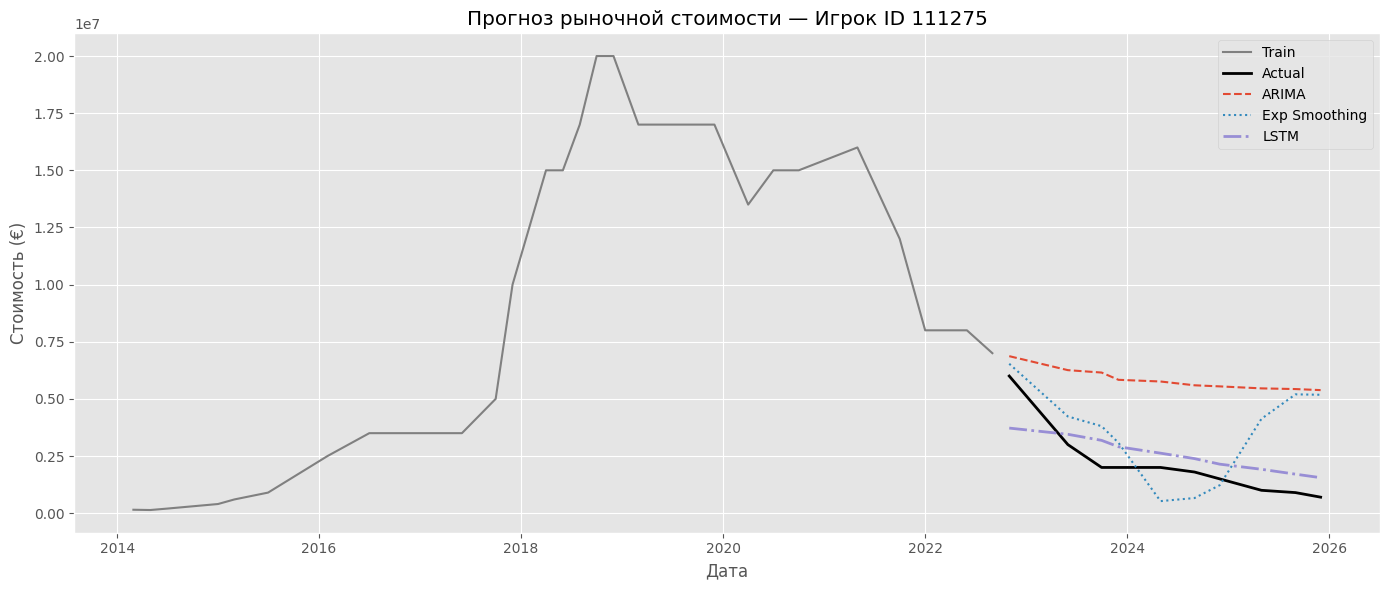

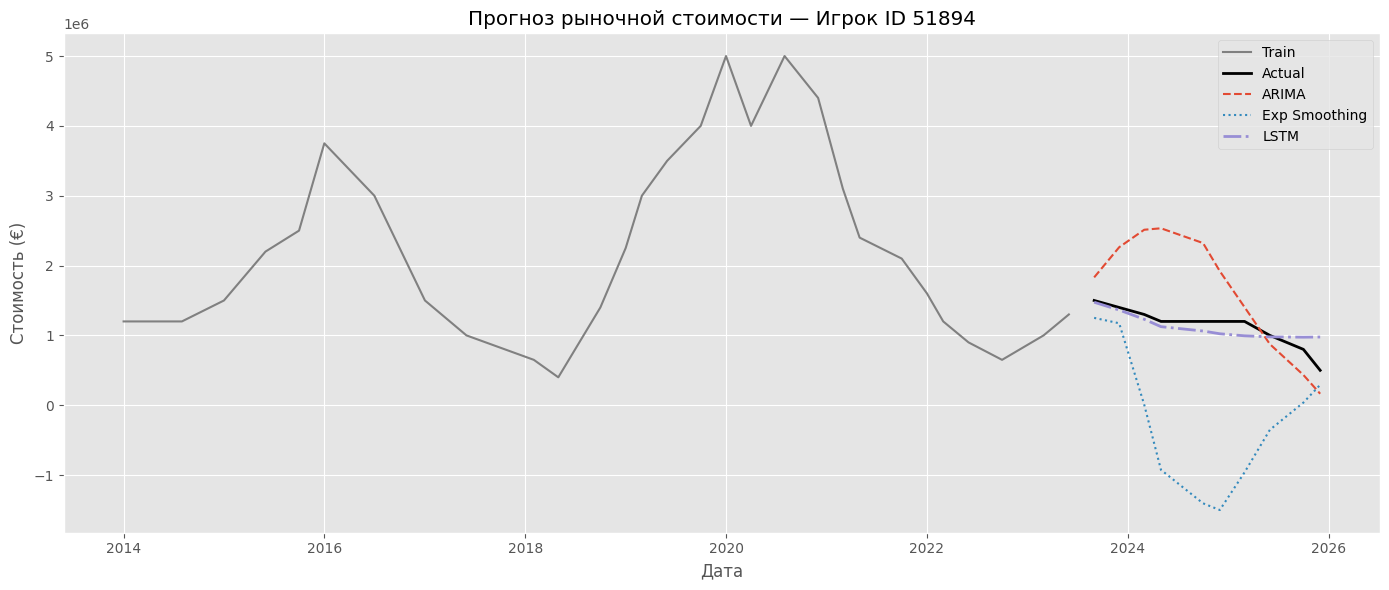

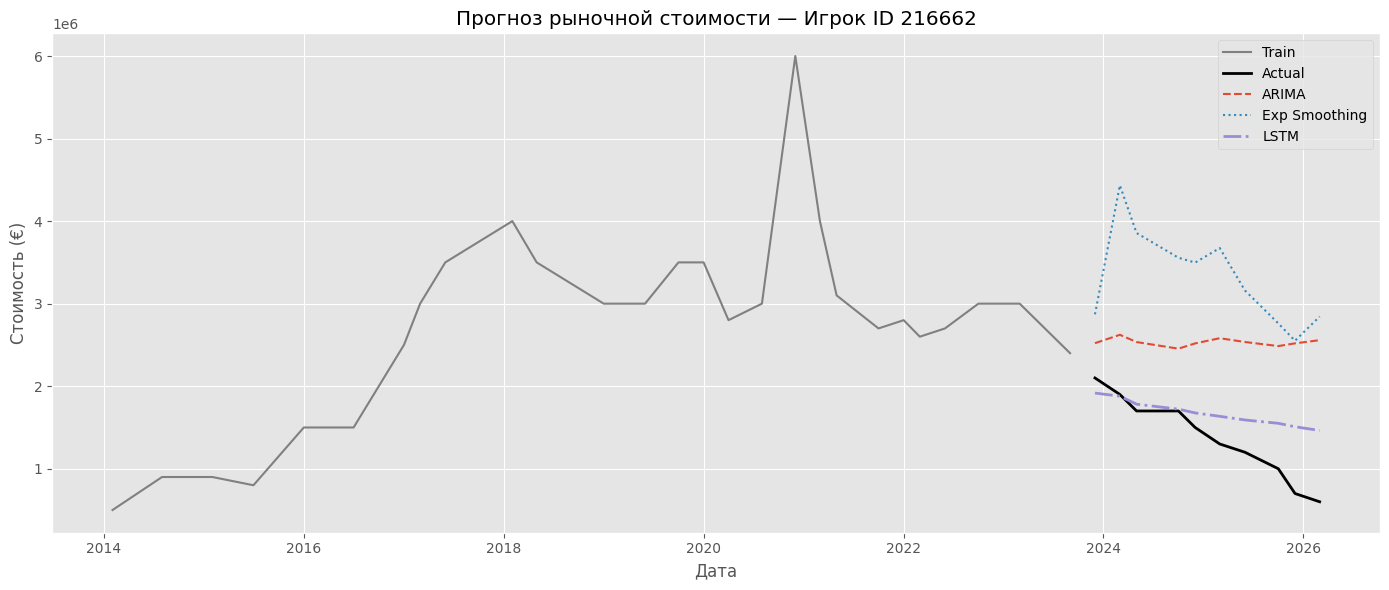

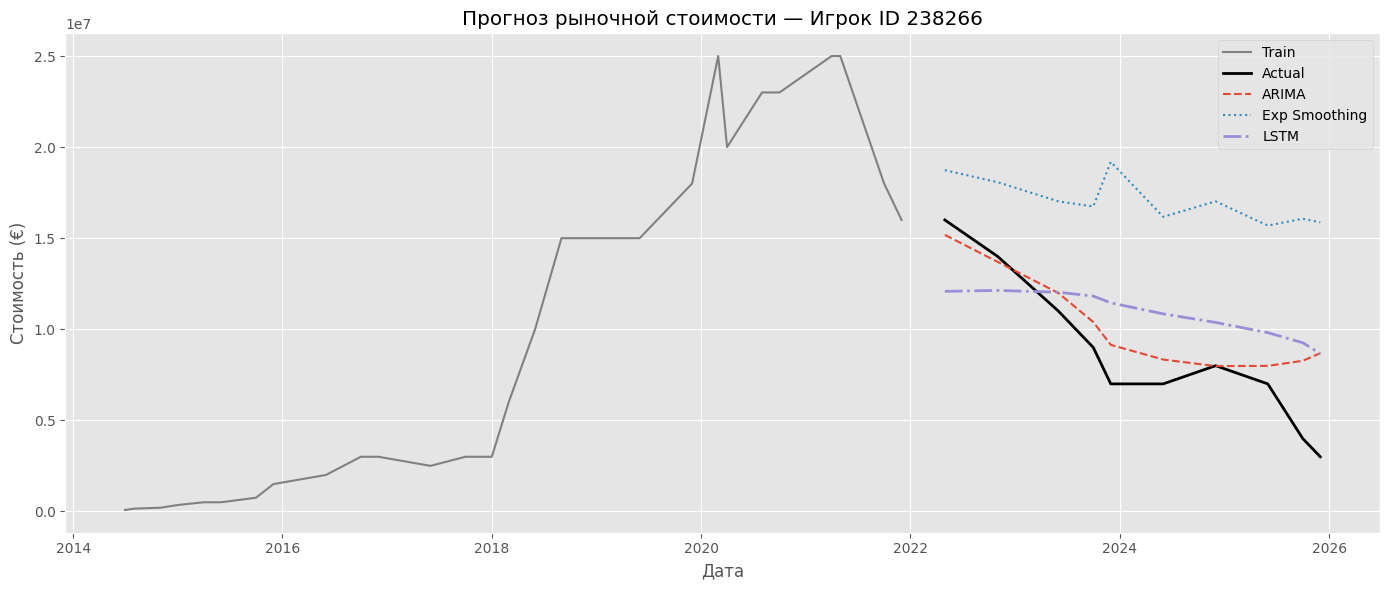

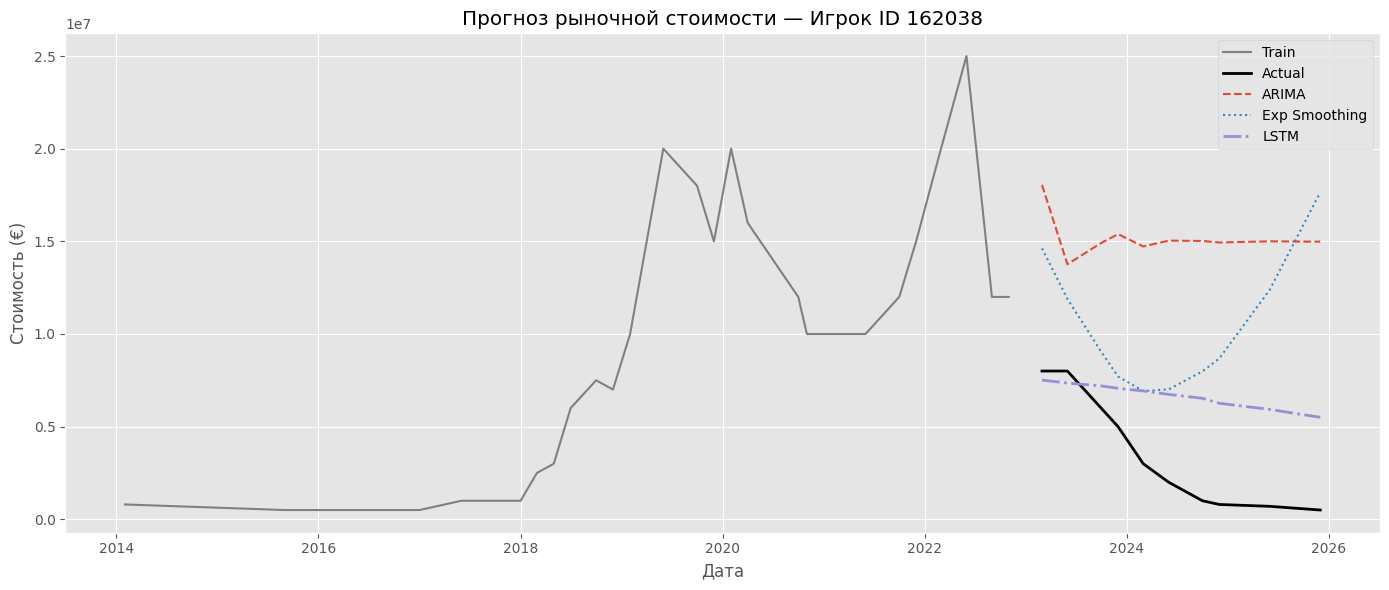

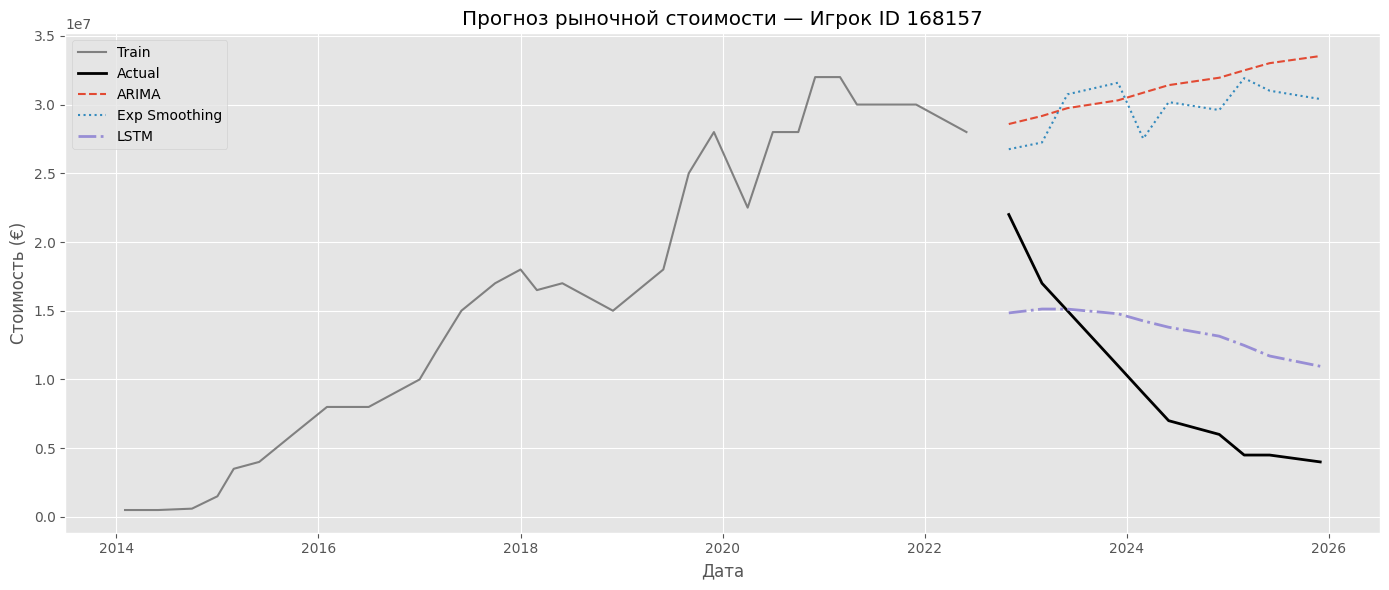

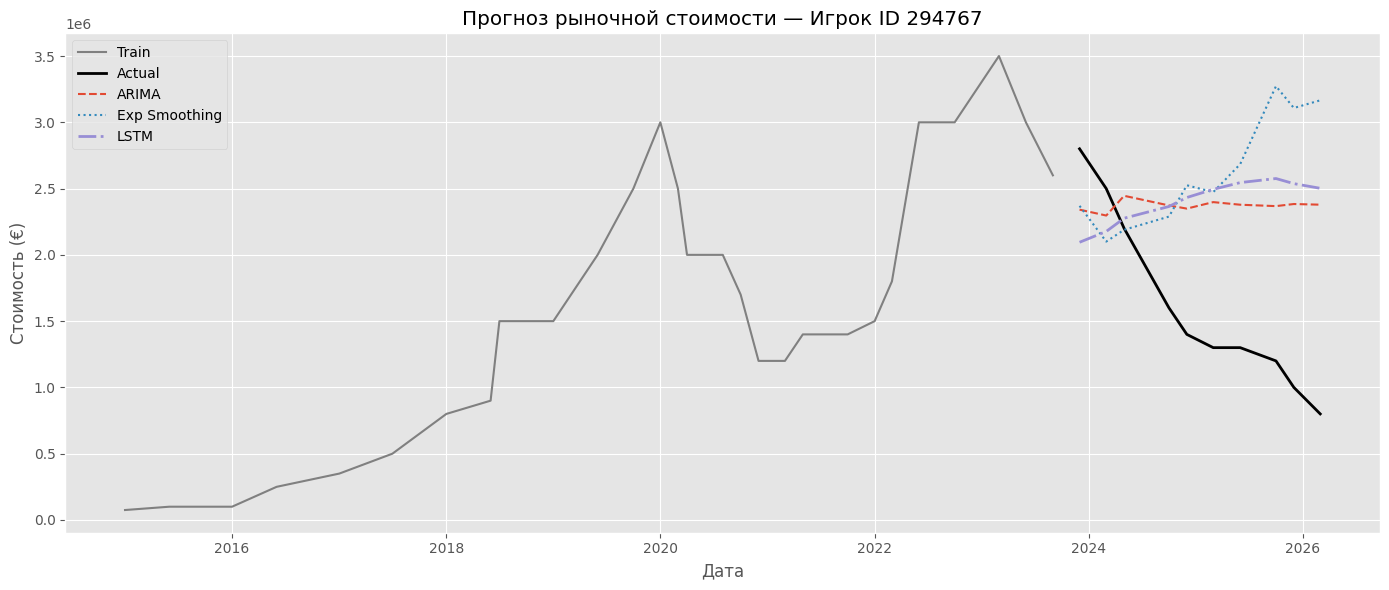

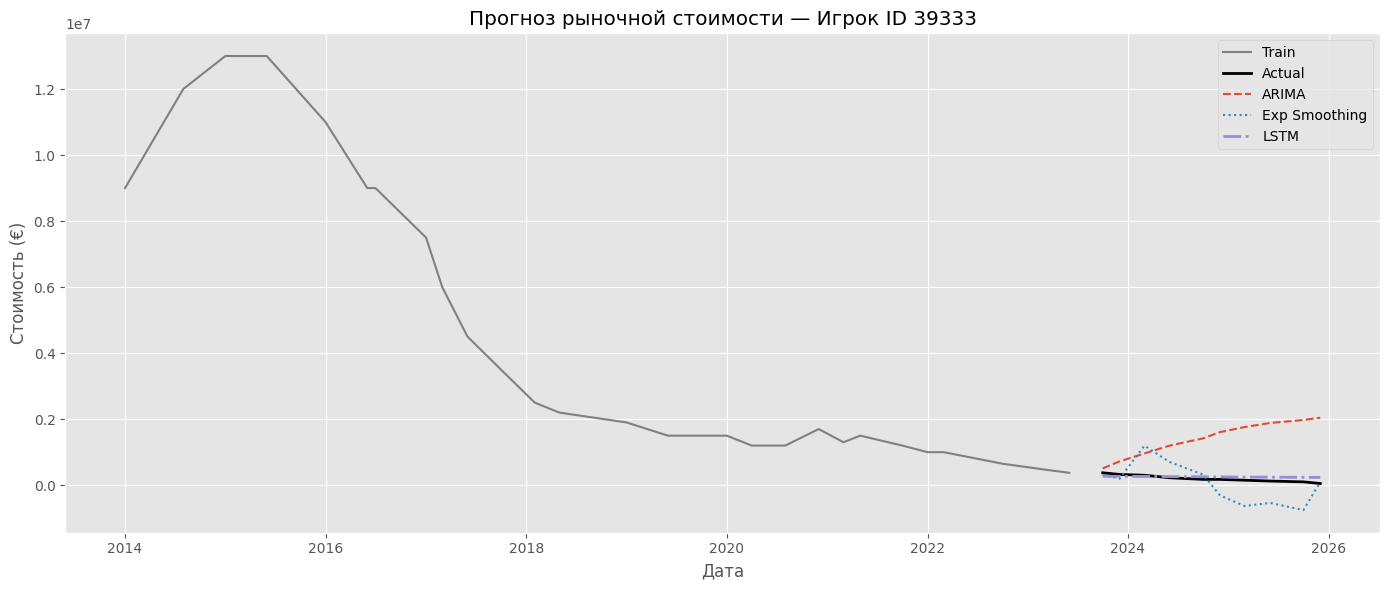

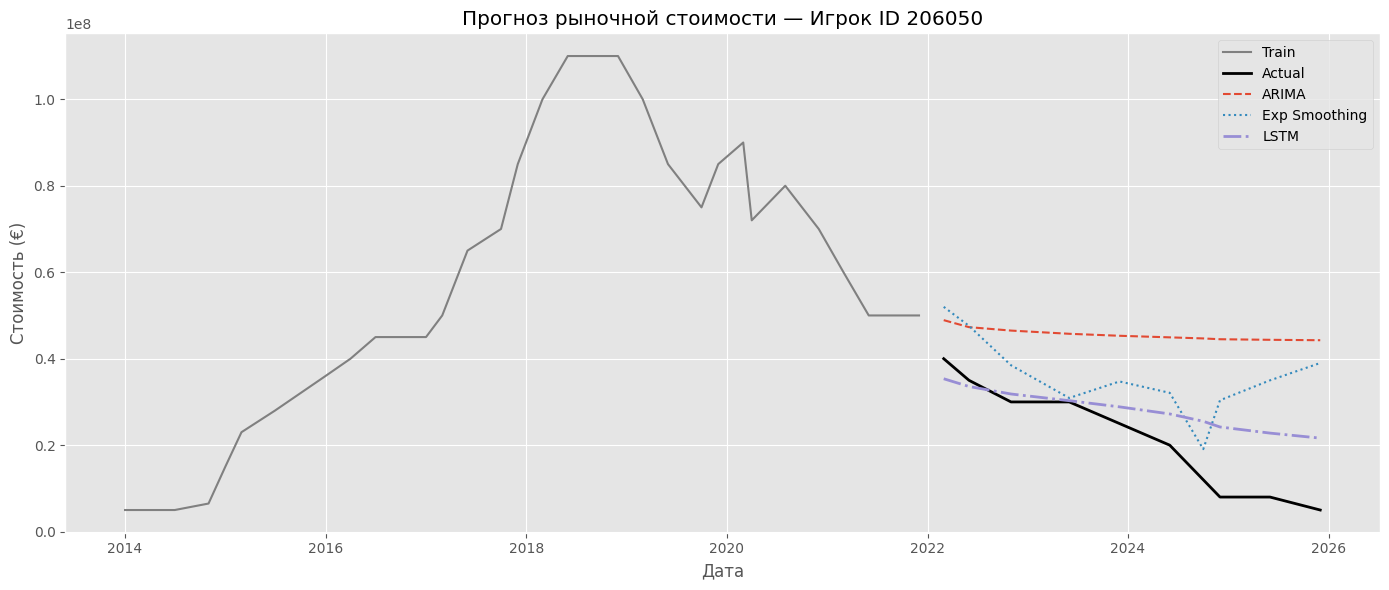

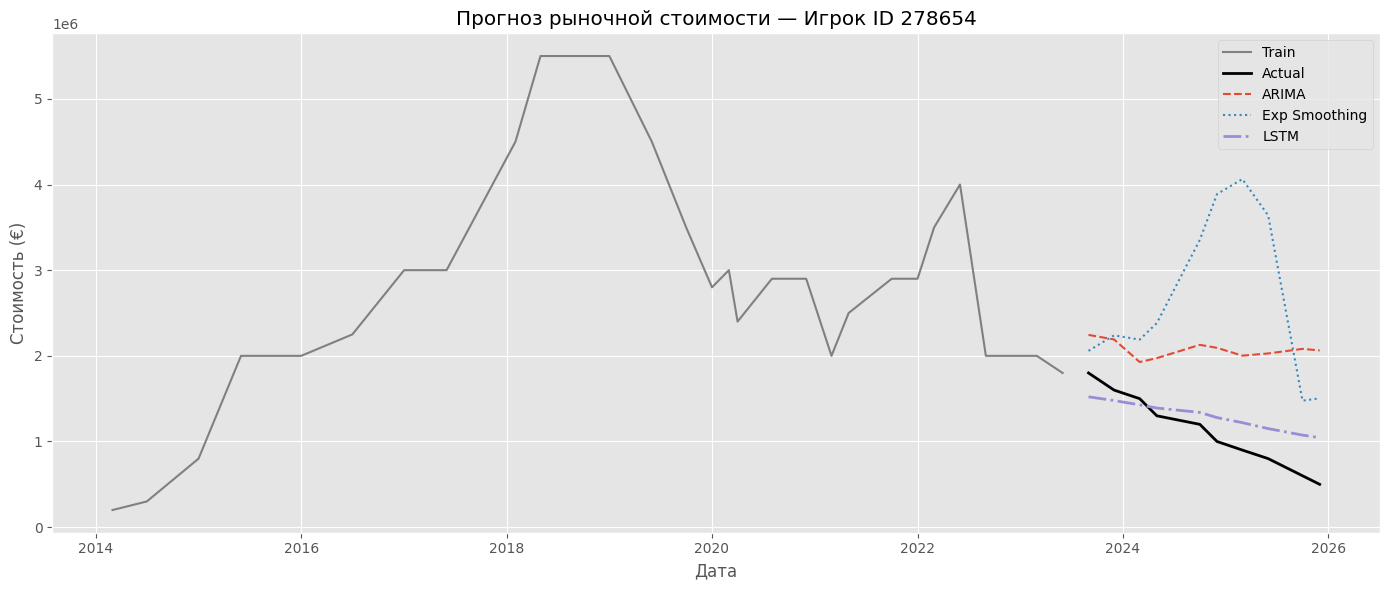

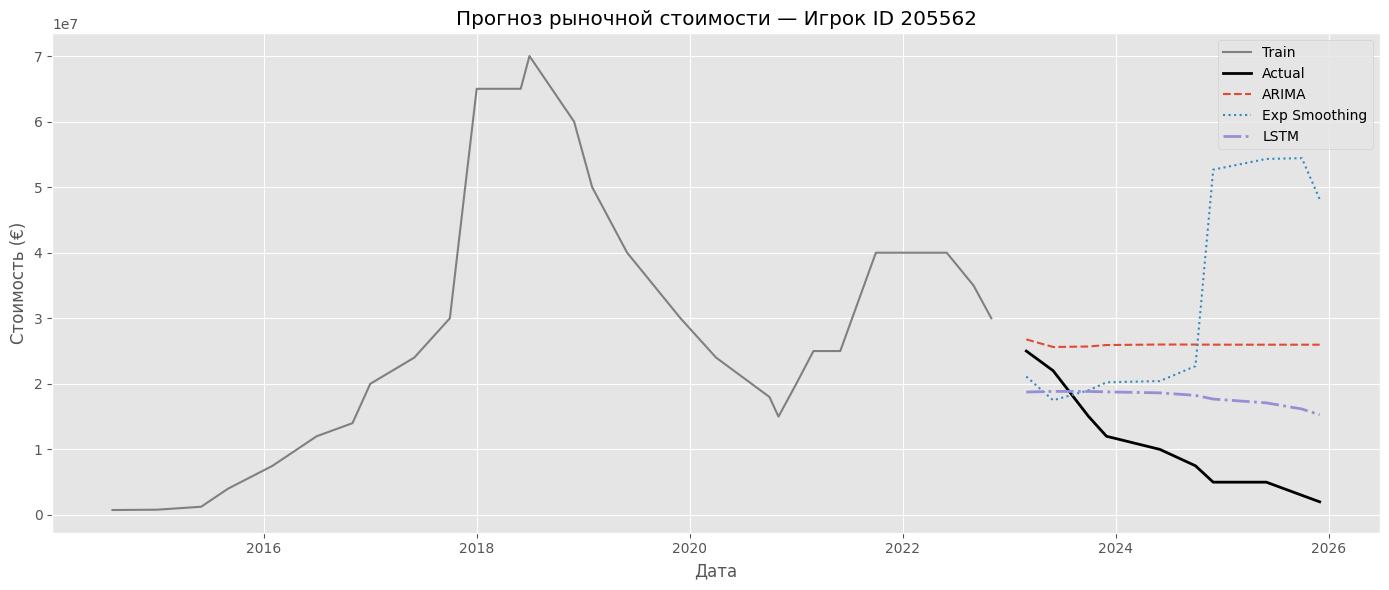

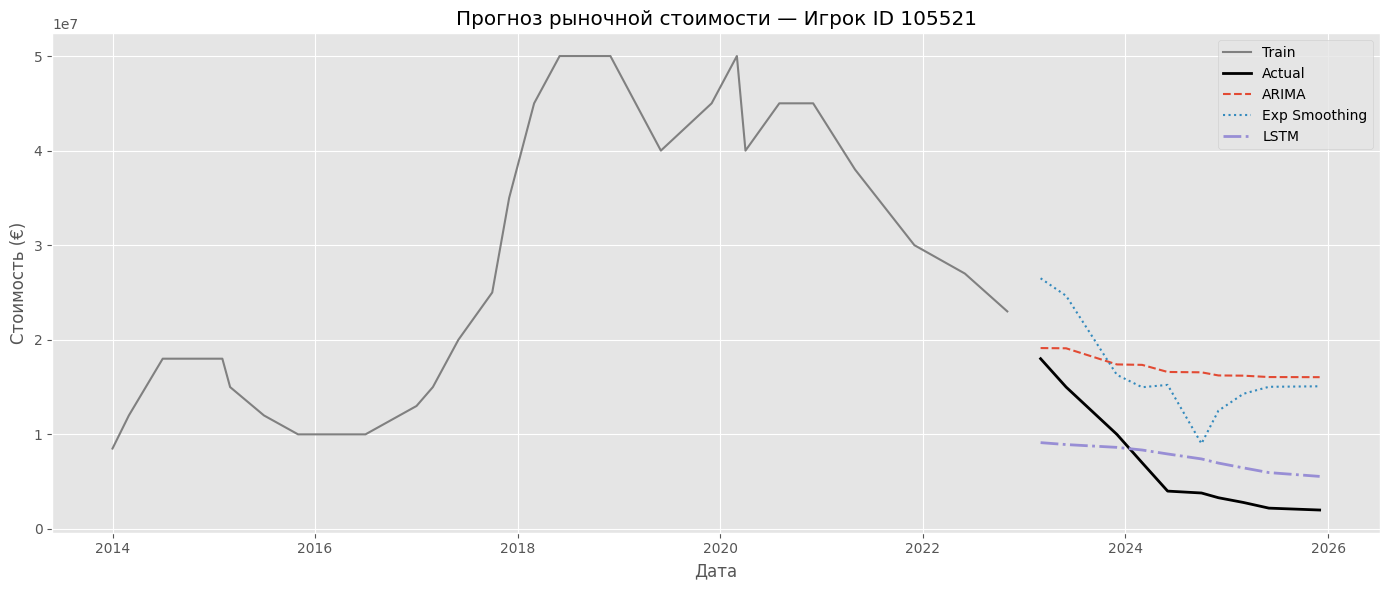

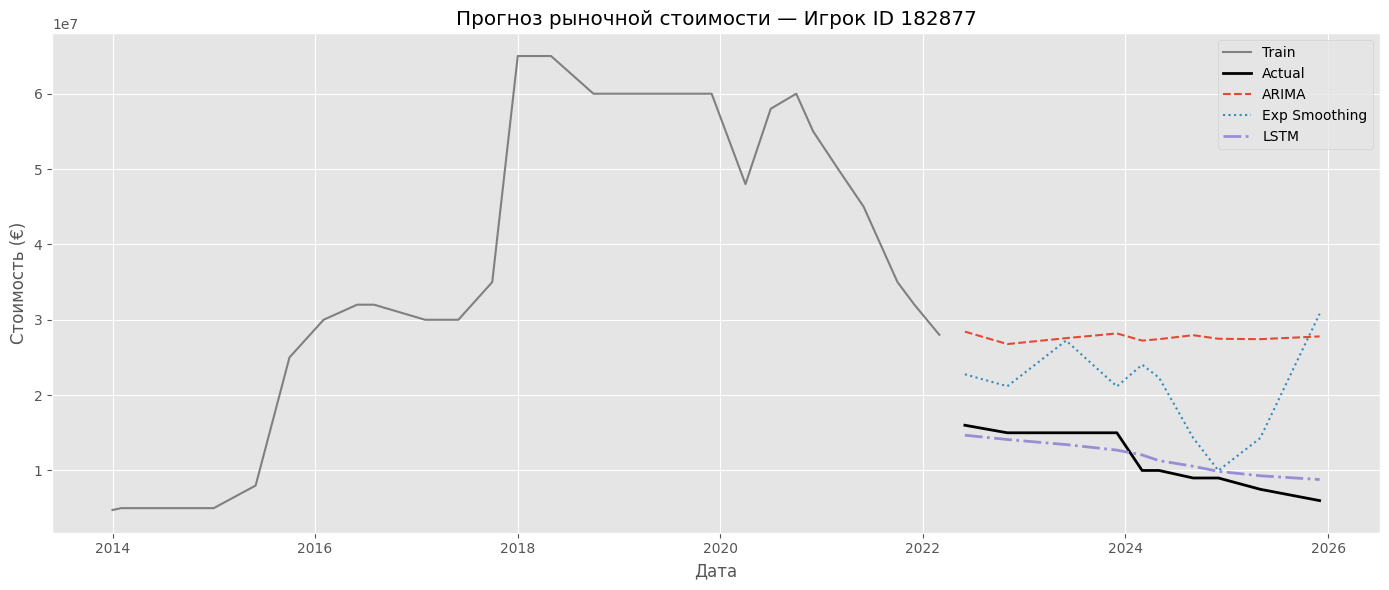

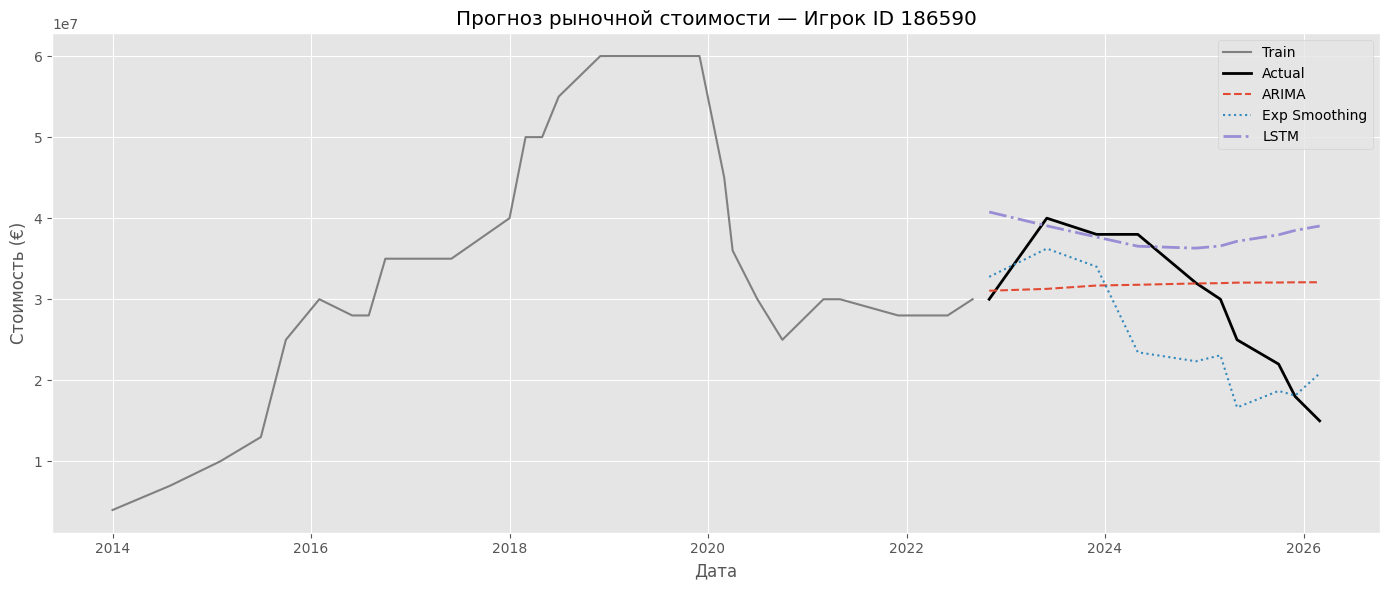

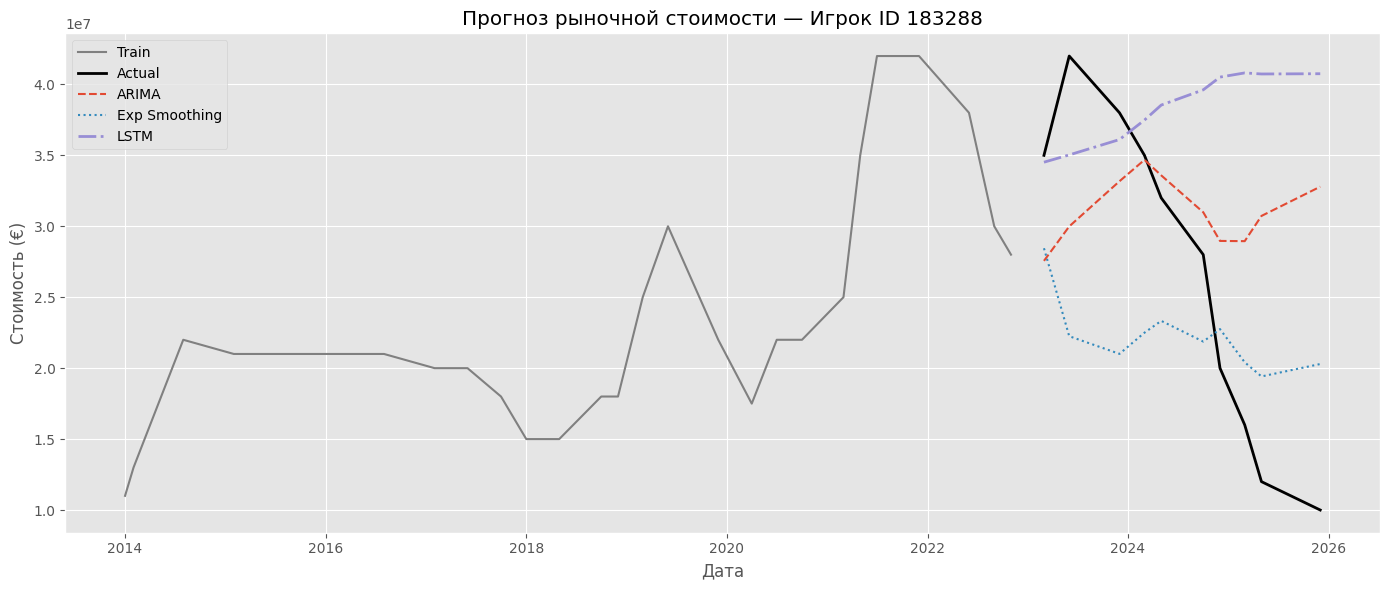

In [ ]:
#%% Ячейка 7: Сравнительные графики прогнозов

for pid in top_player_ids:
    if pid not in results:
        continue
    data = results[pid]
    train = data['train']
    test = data['test']
    
    plt.figure(figsize=(14, 6))
    plt.plot(train.index, train['market_value_in_eur'], label='Train', color='gray')
    plt.plot(test.index, test['market_value_in_eur'], label='Actual', color='black', lw=2)
    plt.plot(test.index, data['arima_pred'], label='ARIMA', ls='--')
    plt.plot(test.index, data['exp_pred'], label='Exp Smoothing', ls=':')
    plt.plot(test.index, data['lstm_pred'], label='LSTM', ls='-.', lw=2)
    
    plt.title(f'Прогноз рыночной стоимости — Игрок ID {pid}')
    plt.xlabel('Дата')
    plt.ylabel('Стоимость (€)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(vis_dir, f'forecast_{pid}.png'), dpi=300)
    plt.show()